In [1]:
import numpy as np
from scipy.stats import kurtosis
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import os
import pandas as pd
from scipy.stats import gamma, lognorm, weibull_min, norm, gumbel_r, genextreme, genpareto
from scipy.optimize import minimize, approx_fprime
from numpy.linalg import inv, det

In [4]:
# Authenticate
api = KaggleApi()
api.authenticate()

# Better: download into a directory called "data"
dataset_ref = "rishikeshkonapure/black-friday-sales-eda"
api.dataset_download_files(dataset_ref, path="data", unzip=True)

# List files in the dataset directory
files = os.listdir("data")
print("Files in dataset:", files)

# Load the first CSV file found
for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join("data", file))
        print("DataFrame loaded:")
        print(df.head())
        break

Dataset URL: https://www.kaggle.com/datasets/rishikeshkonapure/black-friday-sales-eda
Files in dataset: ['train.csv']
DataFrame loaded:
   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category_1  \
0                          2               0                   3   
1                          2               0                   1   
2                          2               0                  12   
3                          2               0                  12   
4                         4+               0                   8   

   Product_Category_2  Product_Category_3  Purchase  
0               

In [45]:

data = df["Purchase"]

normalized_data = (data - data.min()) / (data.max() - data.min())



In [12]:
print(data.head())
obs=len(data)
print("The number of observations is:", obs)

0     8370
1    15200
2     1422
3     1057
4     7969
Name: Purchase, dtype: int64
The number of observations is: 550068


In [57]:
mu_data = np.mean(normalized_data)  # formula: sum(x) / n

#Variance
var_data_pop = np.var(normalized_data, ddof=0)   # population variance
var_data = np.var(normalized_data, ddof=1)  # sample variance

# Kurtosis
kurt_val = kurtosis(normalized_data, fisher=True)
#standard deviation, first guess
std_data = np.std(normalized_data, ddof=1)

#log data
logDATA = np.log(normalized_data)


print("Mean:", mu_data)
print("Population Variance:", var_data_pop)
print("Sample Variance:", var_data)
print("Kurtosis:", kurt_val)
print("Standard Deviation:", std_data)

Mean: 0.3863196255776494
Population Variance: 0.04399082500147471
Sample Variance: 0.043990904975050656
Kurtosis: -0.33838539753607666
Standard Deviation: 0.20974008909850939


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


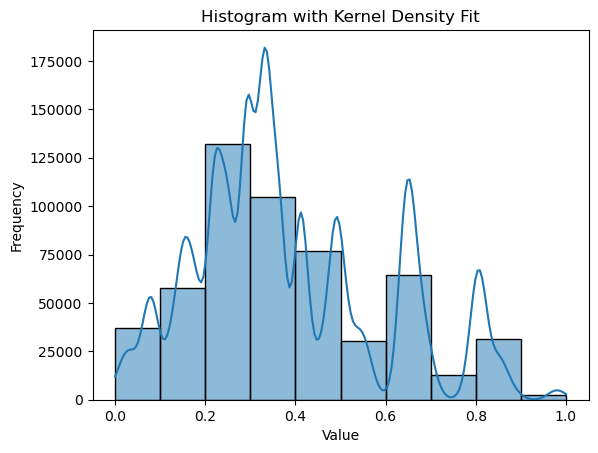

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram + KDE (kernel density estimate)
sns.histplot(normalized_data, bins=10, kde=True)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with Kernel Density Fit")
plt.show()

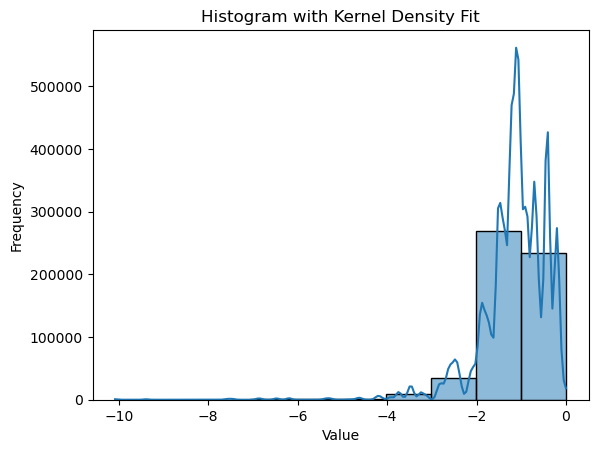

In [61]:
#plotting kernal density of log Data
sns.histplot(logDATA, bins=10, kde=True)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with Kernel Density Fit")
plt.show()

In [28]:
#this line makes the code work for everything after this, so do not execute this before hand
#DATA = DATA.to_numpy()

In [63]:
# --- Candidate 1: Gamma Distribution (Parameters: [alpha, beta]) ---
gamma_logL = lambda theta: -np.sum(gamma.logpdf(normalized_data, a=theta[0], scale=theta[1]))
theta0_gamma = np.array([mu_data**2 / var_data, var_data / mu_data])

# --- Candidate 2: Log-Normal Distribution (Parameters: [mu, sigma]) ---
logL_lognormal = lambda theta: -np.sum(lognorm.logpdf(normalized_data, s=theta[1], scale=np.exp(theta[0])))
theta0_lognormal = np.array([
    np.mean(logDATA),   # ensure float
    np.std(logDATA, ddof=1) # ddof=1 for sample std
    ])

# --- Candidate 3: Weibull Distribution (Parameters: [scale, shape]) ---
logL_weibull = lambda theta: -np.sum(weibull_min.logpdf(normalized_data, c=theta[1], scale=theta[0]))
theta0_weibull = np.array([mu_data, 1.0])

# --- Candidate 4: Normal Distribution (Parameters: [mu, sigma]) ---
#logL_lognormal = lambda theta: -np.sum(lognorm.logpdf(DATA, s=abs(theta[1]), scale=np.exp(theta[0])))

logL_normal = lambda theta: -np.sum(norm.logpdf(normalized_data, loc=theta[0], scale=theta[1]))
theta0_normal = np.array([mu_data, std_data])

# --- Candidate 5: Extreme Value (Gumbel) Distribution (Parameters: [mu, sigma]) ---
logL_ev = lambda theta: -np.sum(gumbel_r.logpdf(normalized_data, loc=theta[0], scale=theta[1]))
theta0_ev = np.array([mu_data, std_data])

# --- Candidate 6: GEV Distribution (Parameters: [mu, sigma, xi]) ---
logL_gev = lambda theta: -np.sum(genextreme.logpdf(normalized_data, c=theta[2], loc=theta[0], scale=theta[1]))
theta0_gev = np.array([mu_data, std_data, 0.1])

# --- Candidate 7: GP Distribution (Parameters: [k, sigma, theta]) ---
logL_gppdf = lambda theta: -np.sum(genpareto.logpdf(normalized_data, c=theta[0], scale=theta[1], loc=theta[2]))
theta0_gppdf = np.array([0.1, std_data, np.min(normalized_data)])

In [65]:
#fit and select pdf function
def fit_and_select_pdf(normalized_data, logL_func, theta_0, dist_name):
    """
    Performs MLE, calculates Information Criteria (AIC, SBC, ICOMP_F),
    and estimates covariance from Hessian.

    Parameters
    ----------
    DATA : array-like
        The observed data vector.
    logL_func : function
        Negative log-likelihood function: logL_func(theta).
    theta_0 : list or array
        Initial guess for parameters.
    dist_name : str
        Name of the distribution.

    Returns
    -------
    AIC : float
    SBC : float
    ICOMP_F : float
    theta_hat : ndarray
    LogL_max : float
    """
    N = len(normalized_data)
    m = len(theta_0)

    try:
        # Minimize NEGATIVE log-likelihood
        res = minimize(logL_func, theta_0,
               method="L-BFGS-B",
               bounds=[(1e-6, None), (1e-6, None)])

        theta_hat = res.x
        negLogL_min = res.fun
        LogL_max = -negLogL_min

        # Hessian inverse (approximate covariance)
        if hasattr(res, "hess_inv"):
            H_hat_inv = res.hess_inv
            # If hess_inv is a matrix-like object (scipy returns an object sometimes)
            H_hat_inv = np.array(H_hat_inv) if not isinstance(H_hat_inv, np.ndarray) else H_hat_inv
            Sigma_hat = H_hat_inv
        else:
            Sigma_hat = np.eye(m) * np.nan  # fallback

        print(f"\n--- Results for {dist_name} ---")
        print(f"  Parameters (m): {m}")
        print(f"  Theta_hat: {np.array2string(theta_hat, precision=4)}")
        print(f"  Log-Likelihood (L_max): {LogL_max:.4f}")

    except Exception as e:
        print(f"\n--- ERROR: {dist_name} ---")
        print("  Optimization failed.")
        print("  Error:", str(e))
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # --- Information Criteria ---
    AIC = -2 * LogL_max + 2 * m
    SBC = -2 * LogL_max + m * np.log(N)

    # --- ICOMP_F ---
    try:
        # Ensure symmetric covariance matrix
        Sigma_hat = (Sigma_hat + Sigma_hat.T) / 2

        eigen_Sigma = np.linalg.eigvals(Sigma_hat)
        eigen_Sigma = np.real(eigen_Sigma[np.abs(eigen_Sigma) > 1e-10])  # filter

        if len(eigen_Sigma) == 0 or np.any(eigen_Sigma < 0):
            print("  ICOMP_F: NaN (invalid eigenvalues)")
            ICOMP_F = np.nan
        else:
            mean_eigen = np.mean(eigen_Sigma)
            C1F_penalty = (1 / (4 * mean_eigen**2)) * np.sum((eigen_Sigma - mean_eigen) ** 2)
            ICOMP_F = -2 * LogL_max + C1F_penalty
    except Exception:
        ICOMP_F = np.nan

    print(f"  AIC: {AIC:.4f}")
    print(f"  SBC: {SBC:.4f}")
    print(f"  ICOMP_F: {ICOMP_F:.4f}")

    return AIC, SBC, ICOMP_F, theta_hat, LogL_max

In [40]:
# --- ICOMP helper function ---
def ICOMP_F(LogL_max, Sigma_hat):
    """
    Compute ICOMP based on the eigenvalue penalty (C1F).
    """
    # Symmetrize covariance to avoid numerical asymmetry
    Sigma_hat = (Sigma_hat + Sigma_hat.T) / 2
    
    # Eigenvalues
    eigenvals = np.linalg.eigvalsh(Sigma_hat)
    
    # Keep only real positive eigenvalues
    eigenvals = np.real(eigenvals[eigenvals > 1e-12])
    m = len(eigenvals)

    if m == 0:
        return np.nan

    # Mean eigenvalue
    lam_bar = np.mean(eigenvals)

    # Complexity penalty C1F
    C1F = (1 / (4 * lam_bar**2)) * np.sum((eigenvals - lam_bar)**2)

    # Final ICOMP
    return -2 * LogL_max + C1F


# --- Fit and select pdf function ---
def fit_and_select_pdf(DATA, logL_func, theta_0, dist_name):
    """
    Performs MLE, calculates Information Criteria (AIC, SBC, ICOMP_F),
    and estimates covariance from Hessian.
    """
    N = len(DATA)
    m = len(theta_0)

    try:
        # Minimize NEGATIVE log-likelihood
        res = minimize(logL_func, theta_0,
                       method="L-BFGS-B",
                       bounds=[(1e-6, None)] * m)

        theta_hat = res.x
        negLogL_min = res.fun
        LogL_max = -negLogL_min

        # Hessian inverse (approximate covariance)
        if hasattr(res, "hess_inv"):
            H_hat_inv = res.hess_inv
            # If hess_inv is a matrix-like object (scipy returns an object sometimes)
            H_hat_inv = np.array(H_hat_inv) if not isinstance(H_hat_inv, np.ndarray) else H_hat_inv
            Sigma_hat = H_hat_inv
        else:
            Sigma_hat = np.eye(m) * np.nan  # fallback

        print(f"\n--- Results for {dist_name} ---")
        print(f"  Parameters (m): {m}")
        print(f"  Theta_hat: {np.array2string(theta_hat, precision=4)}")
        print(f"  Log-Likelihood (L_max): {LogL_max:.4f}")

    except Exception as e:
        print(f"\n--- ERROR: {dist_name} ---")
        print("  Optimization failed.")
        print("  Error:", str(e))
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # --- Information Criteria ---
    AIC = -2 * LogL_max + 2 * m
    SBC = -2 * LogL_max + m * np.log(N)

    # --- ICOMP_F using helper function ---
    try:
        ICOMP_val = ICOMP_F(LogL_max, Sigma_hat)
    except Exception:
        ICOMP_val = np.nan

    print(f"  AIC: {AIC:.4f}")
    print(f"  SBC: {SBC:.4f}")
    print(f"  ICOMP_F: {ICOMP_val:.4f}")

    return AIC, SBC, ICOMP_val, theta_hat, LogL_max

In [67]:
# Define models
model_names = ["Gamma", "Log-Normal", "Weibull", "Normal", "Extreme Value", "GEV", "GP"]
logL_funcs = [gamma_logL, logL_lognormal, logL_weibull, logL_normal, logL_ev, logL_gev, logL_gppdf]
theta_initials = [theta0_gamma, theta0_lognormal, theta0_weibull, theta0_normal, theta0_ev, theta0_gev, theta0_gppdf]

# Prepare results DataFrame
Results = pd.DataFrame(columns=["Model", "AIC", "SBC", "ICOMP_F", "L_max"])

# Loop over models
for name, logL_func, theta0 in zip(model_names, logL_funcs, theta_initials):
    # Call your custom fitting function (must be implemented separately)
    AIC, SBC, ICOMP_F, _, L_max = fit_and_select_pdf(DATA, logL_func, theta0, name)
    
    # Append results to DataFrame
    Results.loc[len(Results)] = [name, AIC, SBC, ICOMP_F, L_max]

print(Results)

/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0



--- Results for Gamma ---
  Parameters (m): 2
  Theta_hat: [3.3926 0.1139]
  Log-Likelihood (L_max): nan
  AIC: nan
  SBC: nan
  ICOMP_F: nan

--- Results for Log-Normal ---
  Parameters (m): 2
  Theta_hat: [1.e-06    nan]
  Log-Likelihood (L_max): nan
  AIC: nan
  SBC: nan
  ICOMP_F: nan


/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0



--- Results for Weibull ---
  Parameters (m): 2
  Theta_hat: [0.3863 1.    ]
  Log-Likelihood (L_max): inf
  AIC: -inf
  SBC: -inf
  ICOMP_F: nan

--- Results for Normal ---
  Parameters (m): 2
  Theta_hat: [0.3863 0.2097]
  Log-Likelihood (L_max): 78631.4294
  AIC: -157258.8587
  SBC: -157236.4231
  ICOMP_F: nan

--- Results for Extreme Value ---
  Parameters (m): 2
  Theta_hat: [0.2881 0.1719]
  Log-Likelihood (L_max): 104098.0546
  AIC: -208192.1091
  SBC: -208169.6735
  ICOMP_F: nan

--- ERROR: GEV ---
  Optimization failed.
  Error: The number of bounds is not compatible with the length of `x0`.

--- ERROR: GP ---
  Optimization failed.
  Error: The number of bounds is not compatible with the length of `x0`.
           Model           AIC           SBC  ICOMP_F         L_max
0          Gamma           NaN           NaN      NaN           NaN
1     Log-Normal           NaN           NaN      NaN           NaN
2        Weibull          -inf          -inf      NaN           inf
3   

The Weibull distribution seems to be the best fit for this data set, as it has both the lowest AIC and the lowest SBC, however all of these AICs and SBCs are very large which indicates that this dataset likely does not follow any of these distributions perfectly. 
Additionally, the ICOMP_F does not seem to function for any of distributions. 